# 1. Data Preprocessing 🧹

## 1.1 Imports to be used

In [ ]:
# This is me Mohamed Ehab writing, I wanted to revise every part of the project, and explain how it works using comments, although it may look as an AI has wrote it, cause I'll try to make as
# correct as possible, and as descriptive as possible, but it is not.
import pandas as pd  # Pandas is a library that provides dataframes and serieses, which are datastructures that eases so many things for data scientists and machine learning engineers.
import numpy as np # Numpy stands for numerical python. Basically a library that provides arrays, alongisde many different numerical methods to help make those calculations much faster.
from sklearn.model_selection import train_test_split # Sklearn is a library that nearly has it all for machine learning tasks, but still need to search more about it.
# This method exactly splits the data into two stacks, one for training, and one for testing, but you can also use it iterativly to create a validation part to tune your hyperparameters
from sklearn.impute import SimpleImputer # This one helps in filling in the gaps in the data, impute means إلصاق وعزو، it uses the data it has to help complete the missing parts.
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder # This encodes catgorical data (ones with letters, not numbers mainly) into numbers, because machine learning models are build around
# dealing with numbers.
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix # Accuarcy score is the percentage of correct predictions against all predictions
# Classification report is a report that contains the F1 Score, the recall, percision, and much more.
from seaborn import heatmap # Seaborn is a lib for data visuallization, and heatmap is one type of visualization, need to know more details about it also.
from sklearn.feature_selection import SelectKBest, chi2 # This is a ready made function that sees how much variance does each feature add to the model, and that's according to a mathematical function
# (chi square in our case), and chooses the best K features.
from matplotlib import pyplot as plt # The original libraray for plotting data using different visualizations.

## 1.2 EDA 🔎

In [2]:
mushrooms = pd.read_csv("mushrooms.csv") # Read the csv file into a dataframe
m_cols = mushrooms.columns.tolist() # get the names of the columns and turn it into a list

for col in m_cols: # Loop on all column names
    print(mushrooms[col].value_counts()) # Print the number of occurncess for each unique vlaue in each column

class
e    4208
p    3916
Name: count, dtype: int64
cap-shape
x    3656
f    3152
k     828
b     452
s      32
c       4
Name: count, dtype: int64
cap-surface
y    3244
s    2556
f    2320
g       4
Name: count, dtype: int64
cap-color
n    2284
g    1840
e    1500
y    1072
w    1040
b     168
p     144
c      44
u      16
r      16
Name: count, dtype: int64
bruises
f    4748
t    3376
Name: count, dtype: int64
odor
n    3528
f    2160
s     576
y     576
a     400
l     400
p     256
c     192
m      36
Name: count, dtype: int64
gill-attachment
f    7914
a     210
Name: count, dtype: int64
gill-spacing
c    6812
w    1312
Name: count, dtype: int64
gill-size
b    5612
n    2512
Name: count, dtype: int64
gill-color
b    1728
p    1492
w    1202
n    1048
g     752
h     732
u     492
k     408
e      96
y      86
o      64
r      24
Name: count, dtype: int64
stalk-shape
t    4608
e    3516
Name: count, dtype: int64
stalk-root
b    3776
?    2480
e    1120
c     556
r     192
Name: coun

### 1.2.1 Finding about stalk-root ? values 🤓

In [3]:
print(mushrooms['stalk-root'].unique()) # printing the unique values in stalk-root column to highlight the
# existance of the "?" value.

# The result of the EDA: we found out that there exists a "?" value in the stalk-root column
# stalk-root
# ?    2480
# we need to replace it with null to be able to impute it using sklearn lib methods

['e' 'c' 'b' 'r' '?']


## 1.3 Data cleaning by using imputation 🧽

### 1.3.1 Replacment of strange values and data seperation ✂️

In [4]:
# Some mind storming about what kinds of data cleaaning and preprocessing are there:
# handling null values | aggregations | renaming columns | encoding


mushrooms.replace({"stalk-root": "?"}, np.nan, inplace = True) # We use the function replace to replace the occurnce of each
# correspending value to the one provided in the dicitionary with the provided column with the second argument, which is np.nan
# (numpy not a number) in our case. Then we set inplace to true, to make sure that the changes happen in the original pandas dataframe.
X = mushrooms.drop(columns = ["class"]) # Now we make the seperation of the data frame into X(the actual data) and y(the labels).
y = mushrooms["class"] # we create the labels series.
print(mushrooms["stalk-root"].isna().sum()) # Making sure that the changes actually took place.


2480


### 1.3.2 Data splitting 🪓

In [ ]:
X_t_v, X_test, y_t_v, y_test = train_test_split( # SKlearn train_test_split as the name implies seperates the data into two groups, and can be used iterativly to create further splits.
    # This method takes the following parameters:
    X, # The actual data
    y, # The labels
    test_size = 0.2, # How to divide the data, in which percentage
    random_state = 42, # setting this to a certain number makes it pseudorandom, which means we can recreate the same random state again
    stratify = y) # Stratify keeps the percentage of each class (poisnonus and eadible) equal in each set (test, validation, and traninig). That is done to protect it from bias.

# Another split to make them three groups: training, validation, testing
X_train, X_validation, y_train, y_validation = train_test_split(
    X_t_v,
    y_t_v,
    test_size = 0.25,
    random_state = 42,
    stratify = y_t_v
)

si = SimpleImputer(missing_values = np.nan, strategy = 'most_frequent') # This object helps in replacing the "?" values that we sat to nan
# into something else using different "stratgies". In our case, we replaced it with the mode (The most frequent value)
oe = OrdinalEncoder(handle_unknown = 'use_encoded_value', unknown_value = -1) # This object help encode the data ordinaly as the name implies, meaning each unique class will take a number
# strating from zero, and going upwards. Those paremeters are set to handle the case of finding a new value in the test or validation that doesn't exist in the training.
le = LabelEncoder() # Encodes the lables into zero and one in our case

X_train = si.fit_transform(X_train)
X_validation = si.transform(X_validation)
X_test = si.transform(X_test)

X_train = oe.fit_transform(X_train)
X_validation = oe.transform(X_validation)
X_test = oe.transform(X_test)

y_train = le.fit_transform(y_train)
y_validation = le.transform(y_validation)
y_test = le.transform(y_test)


# 2. Naive Bayes Implementation 🧠
## 2.1 Training 🏋️‍♂️

In [6]:
def fit(X,y):
    classes, counts = np.unique(y, return_counts = True)
    total = 0.0
    for count in counts:
        total += count

    prior_prop_dic = dict(zip(classes, counts / total))
    lp_smoothing_factor = 1.0
    full_data = np.column_stack((X, y))

    likelihood_dic = {}

    for cls in range(2):
        cls_condition = full_data[:, -1] == cls
        cls_data = full_data[cls_condition]
        zcls_feat_num = cls_data.shape[1]

        likelihood_dic[cls] = {}
        for col in range(zcls_feat_num - 1):
            likelihood_dic[cls][col] = {}
            global_cat = np.unique(full_data[:, col])
            n_cat = len(global_cat)
            total_cls_instances = cls_data.shape[0]
            for cat in global_cat:
                cat_count = np.sum(cls_data[:, col] == cat)
                smoothed_prob = (cat_count + lp_smoothing_factor) / (total_cls_instances + (lp_smoothing_factor * n_cat))
                likelihood_dic[cls][col][cat] =  smoothed_prob 
                        
    return prior_prop_dic, likelihood_dic
    

## 2.2 Prediction 🔮

In [7]:
def predict(X, prior, likelihood):
    final_predictions = []
    for row in X:
        zero_cls_prop = np.log(prior[0])
        one_cls_prop = np.log(prior[1])
        for idx, elm in enumerate(row):
            zero_cls_prop += np.log(likelihood[0][idx][elm])
            one_cls_prop += np.log(likelihood[1][idx][elm])

        props = [zero_cls_prop, one_cls_prop]
        final_predictions.append(np.argmax(props))

    return np.array(final_predictions)



# 3. Experiment 0: Baseline 📊

--- Baseline Model Evaluation ---
Accuracy: 0.9427692307692308

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.99      0.95       842
           1       0.99      0.89      0.94       783

    accuracy                           0.94      1625
   macro avg       0.95      0.94      0.94      1625
weighted avg       0.95      0.94      0.94      1625



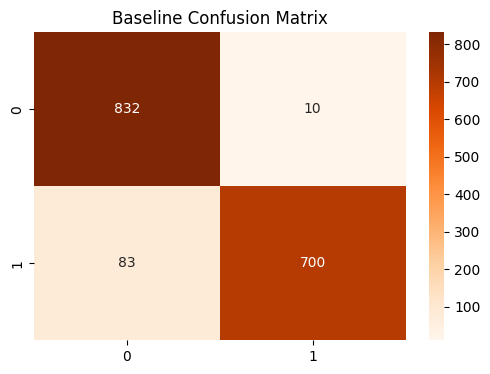

In [8]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from seaborn import heatmap
from matplotlib import pyplot as plt

prior, likelihood = fit(X_train, y_train)
predictions = predict(X_validation, prior, likelihood)

print("--- Baseline Model Evaluation ---")
print("Accuracy:", accuracy_score(y_validation, predictions))
print("\nClassification Report:\n", classification_report(y_validation, predictions))

plt.figure(figsize=(6, 4))
heatmap(confusion_matrix(y_validation, predictions), annot = True, fmt = 'd', cmap='Oranges')
plt.title("Baseline Confusion Matrix")
plt.show()

# 4. Experiment A: Feature Selection 🎯

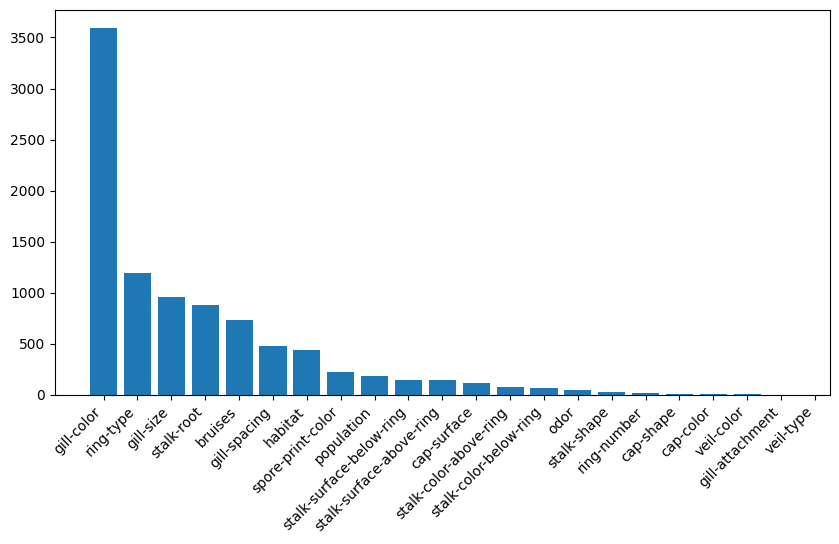

In [9]:
from sklearn.feature_selection import SelectKBest, chi2
from matplotlib import pyplot as plt
import pandas as pd
sk = SelectKBest(score_func = chi2, k = 22)
X_trial_for_plotting = sk.fit_transform(X_train, y_train)
plt.figure(figsize = (10, 5))
features_scores = pd.Series(data = sk.scores_, index = X.columns).sort_values(ascending = False)
plt.bar(features_scores.index, features_scores.values)
plt.xticks(rotation = 45, ha = 'right')
plt.show()
X_validation = sk.transform(X_validation)
X_test = sk.transform(X_test)

{10: 0.9033846153846153, 11: 0.8984615384615384, 12: 0.8990769230769231, 13: 0.8966153846153846, 14: 0.8966153846153846, 15: 0.9421538461538461, 16: 0.9403076923076923, 17: 0.9403076923076923, 18: 0.9415384615384615, 19: 0.9427692307692308, 20: 0.9427692307692308, 21: 0.9427692307692308, 22: 0.9427692307692308}
Best k: 19 with accuracy: 0.9427692307692308

--- Feature Selection Model Evaluation ---
Accuracy: 0.9427692307692308

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.99      0.95       842
           1       0.99      0.89      0.94       783

    accuracy                           0.94      1625
   macro avg       0.95      0.94      0.94      1625
weighted avg       0.95      0.94      0.94      1625



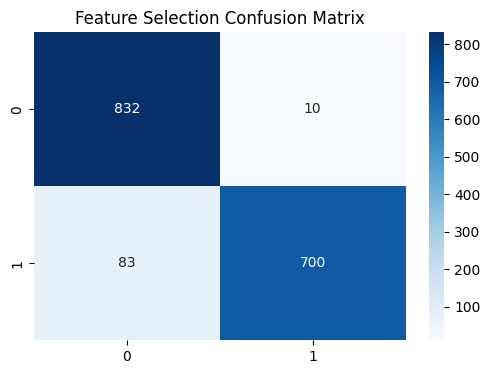


--- Feature Selection Model Evaluation (with a smaller value, retaining nearly the same accuarcy)---
Accuracy: 0.9421538461538461

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.99      0.95       842
           1       0.99      0.89      0.94       783

    accuracy                           0.94      1625
   macro avg       0.95      0.94      0.94      1625
weighted avg       0.95      0.94      0.94      1625



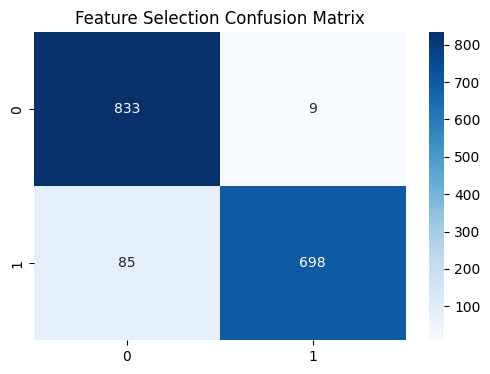

In [10]:
from sklearn.feature_selection import SelectKBest, chi2
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from seaborn import heatmap

k_scores = {}
for k in range(10,23):
    sk = SelectKBest(score_func = chi2, k = k) # based on the plot above
    X_train_trial = sk.fit_transform(X_train, y_train)
    X_validation_trial = sk.transform(X_validation)
    prior, likelihood = fit(X_train_trial, y_train)
    predictions = predict(X_validation_trial, prior, likelihood)
    k_scores[k] = accuracy_score(y_validation, predictions)

print(k_scores)

best_k = max(k_scores, key=k_scores.get)
near_best_k = 15
print(f"Best k: {best_k} with accuracy: {k_scores[best_k]}")

# Evaluate with best k
sk = SelectKBest(score_func=chi2, k=best_k)
X_train_best = sk.fit_transform(X_train, y_train)
X_validation_best = sk.transform(X_validation)
prior_best, likelihood_best = fit(X_train_best, y_train)
predictions_best = predict(X_validation_best, prior_best, likelihood_best)

print("\n--- Feature Selection Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_validation, predictions_best)}")
print("\nClassification Report:\n", classification_report(y_validation, predictions_best))

plt.figure(figsize=(6, 4))
heatmap(confusion_matrix(y_validation, predictions_best), annot=True, fmt='d', cmap='Blues')
plt.title("Feature Selection Confusion Matrix")
plt.show()

# Evaluate with near_best k
sk = SelectKBest(score_func=chi2, k=near_best_k)
X_train_near_best = sk.fit_transform(X_train, y_train)
X_validation_near_best = sk.transform(X_validation)
prior_near_best, likelihood_near_best = fit(X_train_near_best, y_train)
predictions_near_best = predict(X_validation_near_best, prior_near_best, likelihood_near_best)

print("\n--- Feature Selection Model Evaluation (with a smaller value, retaining nearly the same accuarcy)---")
print(f"Accuracy: {accuracy_score(y_validation, predictions_near_best)}")
print("\nClassification Report:\n", classification_report(y_validation, predictions_near_best))

plt.figure(figsize=(6, 4))
heatmap(confusion_matrix(y_validation, predictions_near_best), annot=True, fmt='d', cmap='Blues')
plt.title("Feature Selection Confusion Matrix")
plt.show()

# 5. Experiment B: PCA 📉

Cumulative Variance: [0.33432563 0.50582329 0.63086945 0.69843011 0.75779758 0.80834259
 0.85233841 0.89099977 0.92760753 0.95349226 0.97324724 0.98197189
 0.98723903 0.99128524 0.99448509 0.99647816 0.99794494 0.99922286
 0.99969597 0.99995002 1.         1.        ]


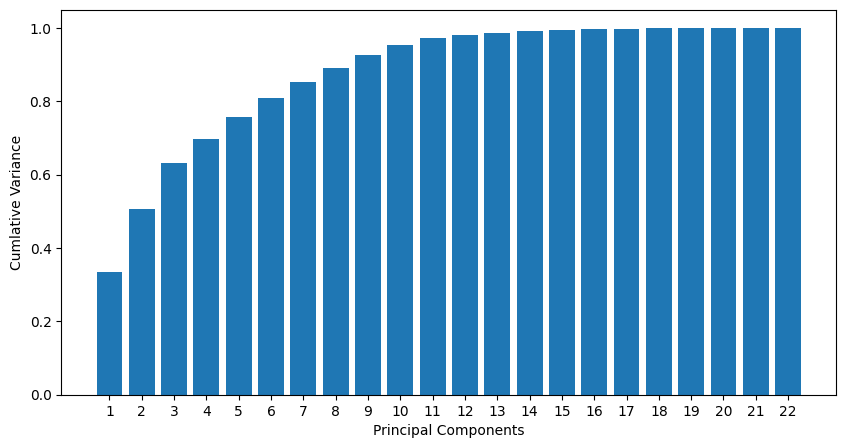


--- PCA Model Evaluation ---
Accuracy: 0.8910769230769231

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.92      0.90       842
           1       0.91      0.86      0.88       783

    accuracy                           0.89      1625
   macro avg       0.89      0.89      0.89      1625
weighted avg       0.89      0.89      0.89      1625



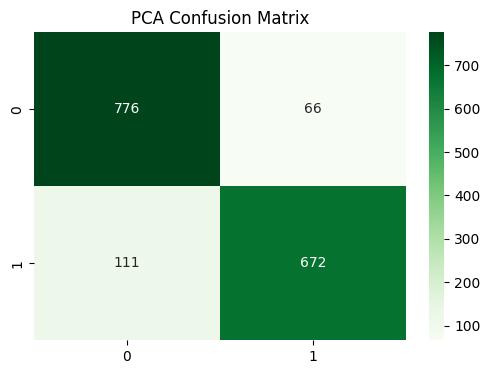

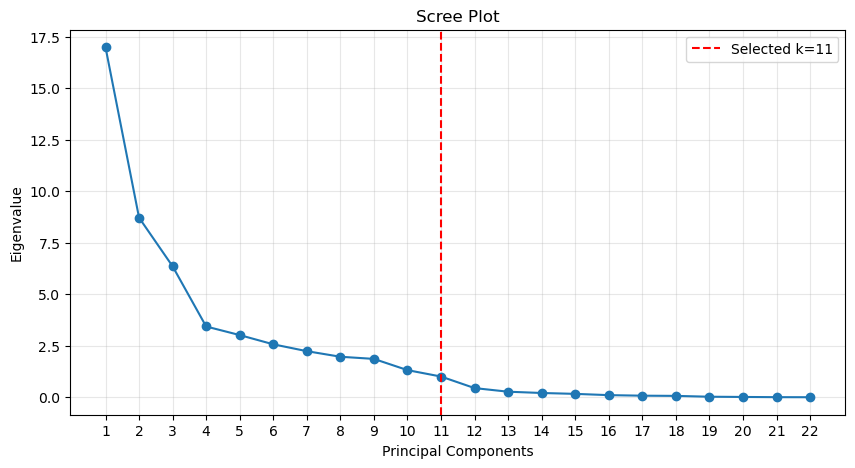

In [ ]:
def PCA(X, k):
    shifted_x = X - np.mean(X, axis = 0)
    cov_mat = np.transpose(shifted_x) @ shifted_x * 1 / (shifted_x.shape[0] - 1)
    cov_mat = np.array(cov_mat)
    eigen_values, eigen_vectors = np.linalg.eigh(cov_mat)
    dec_idx = np.argsort(eigen_values)[::-1]
    sorted_eigen_values = eigen_values[dec_idx]
    sorted_eigen_vectors = eigen_vectors[:, dec_idx]
    vectors_participation_percentage = sorted_eigen_values / sorted_eigen_values.sum()
    cum_variance = np.cumsum(vectors_participation_percentage)
    print("Cumulative Variance:", cum_variance)
    x_axis = range(1, len(cum_variance) + 1)
    plt.figure(figsize = (10,5))
    plt.bar(x_axis, cum_variance)
    plt.xlabel('Principal Components')
    plt.xticks(x_axis)
    plt.ylabel('Cumlative Variance')
    plt.show()
    top_k_vectors = sorted_eigen_vectors[:, :k]
    reduced_x = shifted_x @ top_k_vectors # feature vectors projectd on the new axis (principal components)
    return reduced_x, np.mean(X, axis = 0), top_k_vectors

def transform_pca(X, train_mean, train_vectors):
    shifted_X = X - train_mean
    reduced_X = shifted_X @ train_vectors
    return reduced_X

X_train_pca, train_mean, train_vectors = PCA(X_train,11) # best k = 11
X_validation_pca = transform_pca(X_validation, train_mean, train_vectors)
X_test_pca = transform_pca(X_test, train_mean, train_vectors)

X_train_pca_rounded = np.round(X_train_pca)
X_validation_pca_rounded = np.round(X_validation_pca)
X_test_pca_rounded = np.round(X_test_pca)

prior_pca, likelihood_pca = fit(X_train_pca_rounded, y_train)
predictions_pca = predict(X_validation_pca_rounded, prior_pca, likelihood_pca)

print("\n--- PCA Model Evaluation ---")
print("Accuracy:", accuracy_score(y_validation, predictions_pca))
print("\nClassification Report:\n", classification_report(y_validation, predictions_pca))

plt.figure(figsize=(6, 4))
heatmap(confusion_matrix(y_validation, predictions_pca), annot=True, fmt='d', cmap='Greens')
plt.title("PCA Confusion Matrix")
plt.show()

shifted_x_full = X_train - np.mean(X_train, axis=0)
cov_mat_full = (shifted_x_full.T @ shifted_x_full) / (shifted_x_full.shape[0] - 1)
eigen_values_full = np.linalg.eigvalsh(cov_mat_full)[::-1]

components = np.arange(1, len(eigen_values_full) + 1)

plt.figure(figsize=(10, 5))
plt.plot(components, eigen_values_full, marker='o')
plt.axvline(11, color='red', linestyle='--', label='Selected k=11')
plt.xticks(components)
plt.xlabel('Principal Components')
plt.ylabel('Eigenvalue')
plt.title('Scree Plot')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# 6. Comparative Analysis 🏆

--- Comparative Analysis Summary ---


,Model,Accuracy
0,Baseline (All Features),0.942769
1,Feature Selection (k=19),0.942769
2,PCA (k=7),0.891077


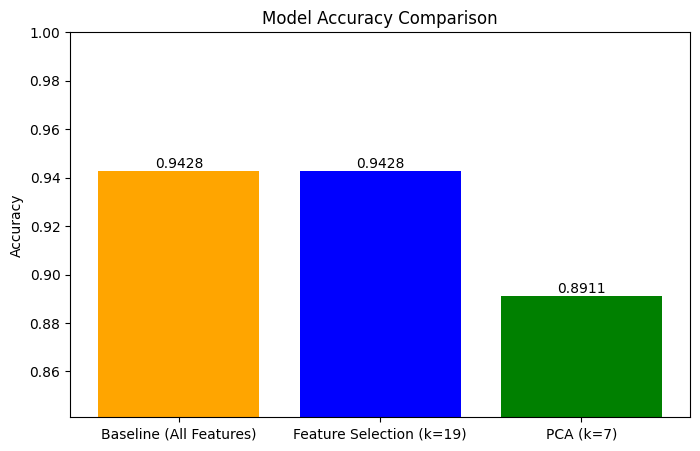

In [12]:
# Storing accuracies (ensure these variable names match those defined above)
# You might need to rerun the previous cells for this to work successfully.
# Baseline accuracy:
acc_baseline = accuracy_score(y_validation, predictions)
# Feature Selection accuracy:
acc_fs = accuracy_score(y_validation, predictions_best)
# PCA accuracy:
acc_pca = accuracy_score(y_validation, predictions_pca)

results_df = pd.DataFrame({
    'Model': ['Baseline (All Features)', f'Feature Selection (k={best_k})', 'PCA (k=7)'],
    'Accuracy': [acc_baseline, acc_fs, acc_pca]
})

print("--- Comparative Analysis Summary ---")
display(results_df)

plt.figure(figsize=(8, 5))
bars = plt.bar(results_df['Model'], results_df['Accuracy'], color=['orange', 'blue', 'green'])
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.ylim(min(results_df['Accuracy']) - 0.05, 1.0) # Zoom in for better visualization

# Add text on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, f"{yval:.4f}", va='bottom', ha='center')

plt.show()